# Lib import

In [95]:
# pandas pour exploiter les données en dataframe
import pandas as pd
import numpy as np
# pour charger certain fichier depuis l'ordinateur
from glob import glob
# affichage des graph
import seaborn as sns
from sklearn.externals.six import StringIO
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
import matplotlib.pyplot as plt
from scipy import stats
# Destiné à lancer nos modeles
from sklearn import tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Dataset import
## 1.  Les enregistrements des fenêtres d'activité

In [2]:
# on charges les activity labels
activity_labels = pd.read_csv("HAPT Data Set/activity_labels.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                              usecols=[0,1], names=["activity_id","activity_labels"])
activity_labels

,activity_id,activity_labels
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING
6,7,STAND_TO_SIT
7,8,SIT_TO_STAND
8,9,SIT_TO_LIE
9,10,LIE_TO_SIT


In [3]:
# on charge les id des sujets pour le de train et test
subject_id_train = pd.read_csv("HAPT Data Set/Train/subject_id_train.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                              usecols=[0], names=["subject_id"])
subject_id_test = pd.read_csv("HAPT Data Set/Test/subject_id_test.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                              usecols=[0], names=["subject_id"])


In [4]:
# on charge la liste de toutes les caractéristiques 
features = pd.read_csv("HAPT Data Set/features.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                              usecols=[0], names=["features"])

col_name = [val[0] for val in features.values]

In [5]:
# on charge la liste de toutes les caractéristiques: Ensemble de formation.
x_train = pd.read_csv("HAPT Data Set/Train/X_train.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                               names=col_name)
x_test = pd.read_csv("HAPT Data Set/Test/X_test.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                               names=col_name)

In [6]:
# on charge les ouputs: ici represent l'id d'une activité

y_train = pd.read_csv("HAPT Data Set/Train/y_train.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                               usecols=[0],names=["activity_id"])
y_test = pd.read_csv("HAPT Data Set/Test/y_test.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                               usecols=[0],names=["activity_id"])

In [7]:
# on crée alors les dataframe test et train
df_train = subject_id_train.join([x_train, y_train])
df_test = subject_id_test.join([x_test, y_test])

## Première aperçu des données

In [8]:
df_train.columns

Index(['subject_id', 'tBodyAcc-Mean-1', 'tBodyAcc-Mean-2', 'tBodyAcc-Mean-3',
       'tBodyAcc-STD-1', 'tBodyAcc-STD-2', 'tBodyAcc-STD-3', 'tBodyAcc-Mad-1',
       'tBodyAcc-Mad-2', 'tBodyAcc-Mad-3',
       ...
       'fBodyGyroJerkMag-Skewness-1', 'fBodyGyroJerkMag-Kurtosis-1',
       'tBodyAcc-AngleWRTGravity-1', 'tBodyAccJerk-AngleWRTGravity-1',
       'tBodyGyro-AngleWRTGravity-1', 'tBodyGyroJerk-AngleWRTGravity-1',
       'tXAxisAcc-AngleWRTGravity-1', 'tYAxisAcc-AngleWRTGravity-1',
       'tZAxisAcc-AngleWRTGravity-1', 'activity_id'],
      dtype='object', length=563)

In [9]:
df_train.shape

(7767, 563)

In [10]:
df_test.shape

(3162, 563)

In [11]:
df_train.head()

,subject_id,tBodyAcc-Mean-1,tBodyAcc-Mean-2,tBodyAcc-Mean-3,tBodyAcc-STD-1,tBodyAcc-STD-2,tBodyAcc-STD-3,tBodyAcc-Mad-1,tBodyAcc-Mad-2,tBodyAcc-Mad-3,...,fBodyGyroJerkMag-Skewness-1,fBodyGyroJerkMag-Kurtosis-1,tBodyAcc-AngleWRTGravity-1,tBodyAccJerk-AngleWRTGravity-1,tBodyGyro-AngleWRTGravity-1,tBodyGyroJerk-AngleWRTGravity-1,tXAxisAcc-AngleWRTGravity-1,tYAxisAcc-AngleWRTGravity-1,tZAxisAcc-AngleWRTGravity-1,activity_id
0,1,0.043580,-0.005970,-0.035054,-0.995381,-0.988366,-0.937382,-0.995007,-0.988816,-0.953325,...,-0.314848,-0.713308,-0.112754,0.030400,-0.464761,-0.018446,-0.841559,0.179913,-0.051718,5
1,1,0.039480,-0.002131,-0.029067,-0.998348,-0.982945,-0.971273,-0.998702,-0.983315,-0.974000,...,-0.603199,-0.860677,0.053477,-0.007435,-0.732626,0.703511,-0.845092,0.180261,-0.047436,5
2,1,0.039978,-0.005153,-0.022651,-0.995482,-0.977314,-0.984760,-0.996415,-0.975835,-0.985973,...,-0.404427,-0.761847,-0.118559,0.177899,0.100699,0.808529,-0.849230,0.180610,-0.042271,5
3,1,0.039785,-0.011809,-0.028916,-0.996194,-0.988569,-0.993256,-0.996994,-0.988526,-0.993135,...,-0.138373,-0.491604,-0.036788,-0.012892,0.640011,-0.485366,-0.848947,0.181907,-0.040826,5
4,1,0.038758,-0.002289,-0.023863,-0.998241,-0.986774,-0.993115,-0.998216,-0.986479,-0.993825,...,-0.366214,-0.702490,0.123320,0.122542,0.693578,-0.615971,-0.848164,0.185124,-0.037080,5


In [12]:
df_test.head()

,subject_id,tBodyAcc-Mean-1,tBodyAcc-Mean-2,tBodyAcc-Mean-3,tBodyAcc-STD-1,tBodyAcc-STD-2,tBodyAcc-STD-3,tBodyAcc-Mad-1,tBodyAcc-Mad-2,tBodyAcc-Mad-3,...,fBodyGyroJerkMag-Skewness-1,fBodyGyroJerkMag-Kurtosis-1,tBodyAcc-AngleWRTGravity-1,tBodyAccJerk-AngleWRTGravity-1,tBodyGyro-AngleWRTGravity-1,tBodyGyroJerk-AngleWRTGravity-1,tXAxisAcc-AngleWRTGravity-1,tYAxisAcc-AngleWRTGravity-1,tZAxisAcc-AngleWRTGravity-1,activity_id
0,2,0.030914,-0.008927,0.040382,-0.938504,-0.944626,-0.759334,-0.952398,-0.950281,-0.802483,...,-0.345684,-0.709087,0.006462,0.162920,-0.825886,0.271151,-0.720559,0.276779,-0.051074,5
1,2,0.042548,0.001079,-0.026236,-0.975516,-0.977502,-0.960146,-0.986694,-0.978983,-0.966820,...,-0.142804,-0.600867,-0.083495,0.017500,-0.434375,0.920593,-0.698684,0.281322,-0.076825,5
2,2,0.038297,-0.011660,-0.025643,-0.993922,-0.979215,-0.973030,-0.994298,-0.980535,-0.977508,...,-0.209525,-0.645500,-0.034956,0.202302,0.064103,0.145068,-0.703355,0.280062,-0.072302,5
3,2,0.036205,-0.018148,-0.025240,-0.994845,-0.981534,-0.976175,-0.995169,-0.983020,-0.980785,...,-0.359352,-0.738474,-0.017067,0.154438,0.340134,0.296407,-0.699545,0.284093,-0.070079,5
4,2,0.038034,-0.013437,-0.032899,-0.993955,-0.977493,-0.984290,-0.994006,-0.977354,-0.985899,...,-0.544467,-0.846150,-0.002223,-0.040046,0.736715,-0.118545,-0.692849,0.290701,-0.066849,5


## Data Visualisation

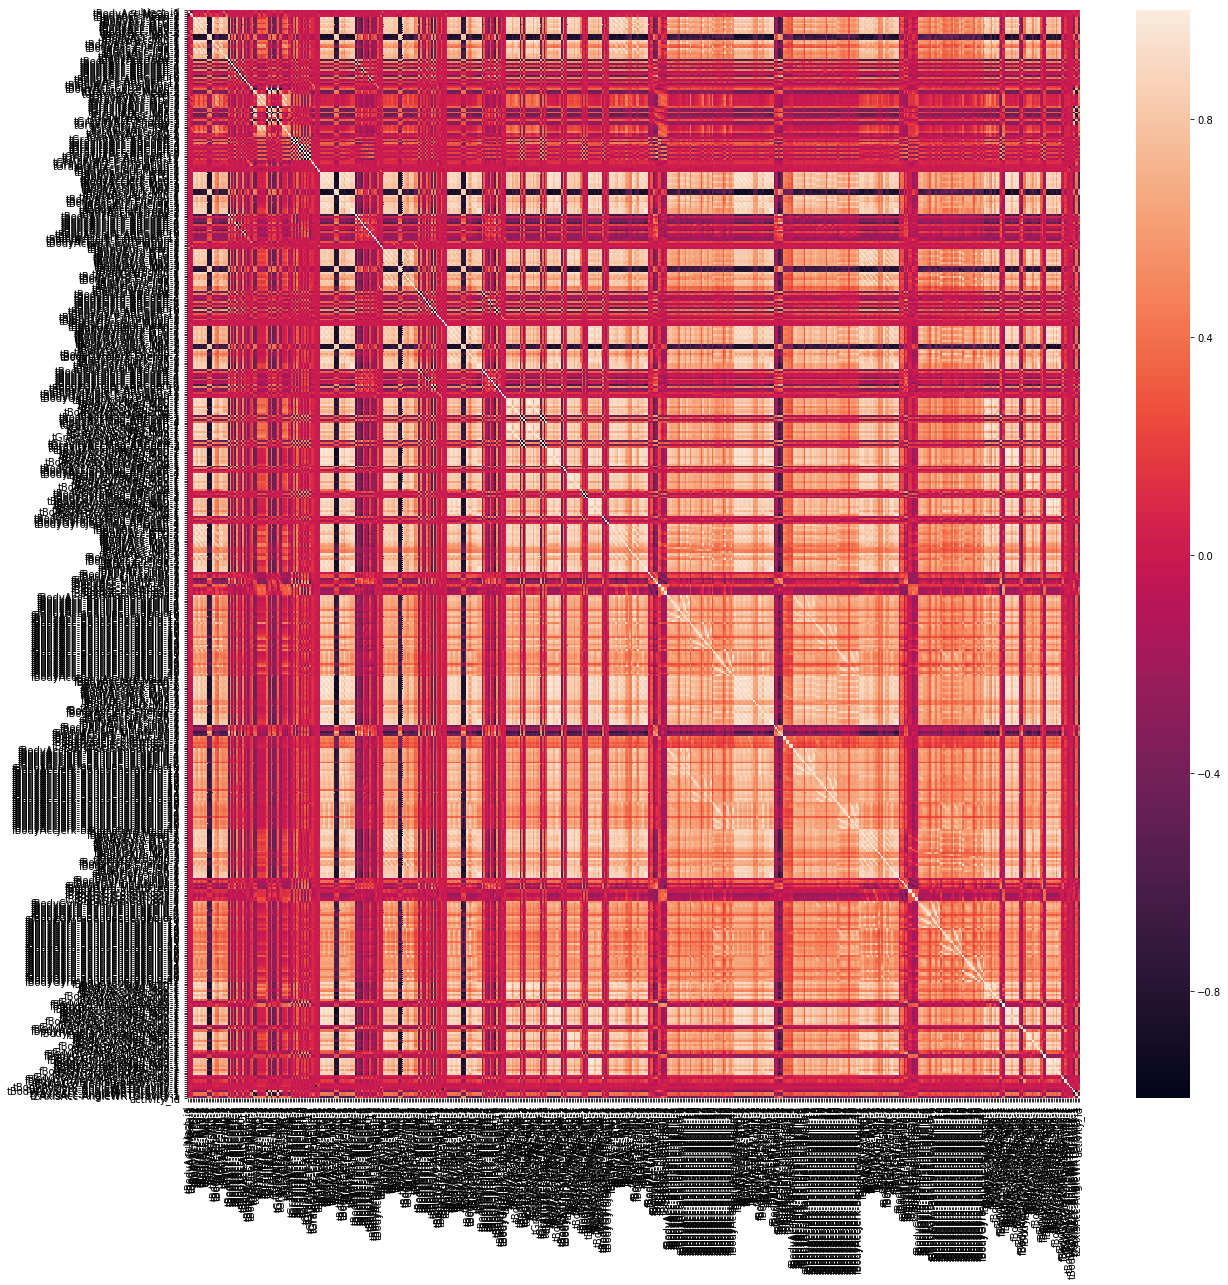

In [13]:
# matrice de correlation
corr = df_train.corr()
# generation d'une heatmap
fig, ax = plt.subplots(figsize=(20,20))  
sns.heatmap(corr,xticklabels=corr.columns, yticklabels=corr.columns)

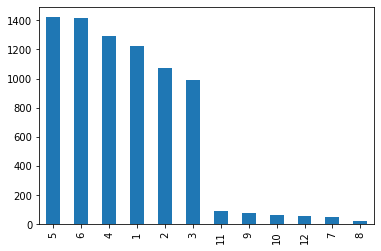

In [14]:
# nombre de ligne par activity
df_train['activity_id'].value_counts().plot(kind="bar")

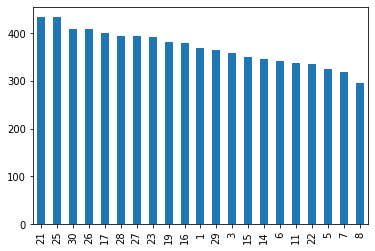

In [15]:
# nombre de ligne par sujet
df_train['subject_id'].value_counts().plot(kind="bar")

/opt/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


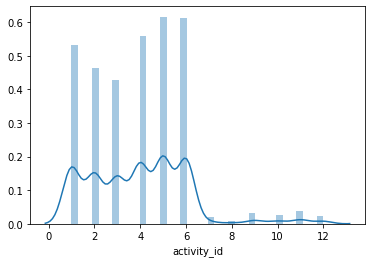

In [16]:
# visualisation de la distributions du dataset
sns.distplot(df_train['activity_id'])

## 2.  Données des capteurs inertiels 

In [17]:
data_dir = 'HAPT Data Set/RawData/'

In [18]:
######################
# Analyse du fichier #
######################
Raw_data_paths = sorted(glob("HAPT Data Set/RawData//*"))
# Selecting acc file paths only
Raw_acc_paths=Raw_data_paths[0:61]

# Selecting gyro file paths only
Raw_gyro_paths=Raw_data_paths[61:122]

# printing info related to acc and gyro files
print (("RawData folder contains in total {:d} file ").format(len(Raw_data_paths)))
print (("The first {:d} are Acceleration files:").format(len(Raw_acc_paths)))
print (("The second {:d} are Gyroscope files:").format(len(Raw_gyro_paths)))
print ("The last file is a labels file")

# printing 'labels.txt' path
print ("labels file path is:",Raw_data_paths[122])

RawData folder contains in total 123 file 
The first 61 are Acceleration files:
The second 61 are Gyroscope files:
The last file is a labels file
labels file path is: HAPT Data Set/RawData/labels.txt


In [19]:
#    FUNCTION: import_raw_signals(path,columns)
#    ###################################################################
#    #           1- Import acc or gyro file                            #
#    #           2- convert from txt format to float format            #
#    #           3- convert to a dataframe & insert le nom des column  #
#    ###################################################################                      

def import_raw_signals(file_path,columns):
    
    # open the txt file
    opened_file =open(file_path,'r')

    # Create a list
    opened_file_list=[]
    
    # loop over each line in the opened_file
    # convert each element from txt format to float 
    # store each raw in a list
    for line in opened_file:
        opened_file_list.append([float(element) for element in line.split()])

    # convert the list of lists into 2D numpy array(computationally efficient)
    data=np.array(opened_file_list)


    # Create a pandas dataframe from this 2D numpy array with column names
    data_frame=pd.DataFrame(data=data,columns=columns)

    # return the data frame
    return data_frame

In [20]:
# creation d'une list avec acc file
raw_acc_columns=['acc_X','acc_Y','acc_Z']

# creation d'une list avec gyro files columns names
raw_gyro_columns=['gyro_X','gyro_Y','gyro_Z']

df_sensor = pd.DataFrame()

# loop for to convert  each "acc file" into data frame of floats and store it in a dictionnary.
for path_index in range(0,61):
    # extracting the file name only and use it as key:[expXX_userXX] without "acc" or "gyro"
    key= Raw_data_paths[path_index][-16:-4]
        
    # Applying the function defined above to one acc_file and store the output in a DataFrame
    raw_acc_data_frame=import_raw_signals(Raw_data_paths[path_index],raw_acc_columns)
        
    # By shifting the path_index by 61 we find the index of the gyro file related to same experiment_ID
    # Applying the function defined above to one gyro_file and store the output in a DataFrame
    raw_gyro_data_frame=import_raw_signals(Raw_data_paths[path_index+61],raw_gyro_columns)
        
    # concatenate acc_df and gyro_df in one DataFrame
    raw_signals_data_frame=pd.concat([raw_acc_data_frame, raw_gyro_data_frame], axis=1)
        
    # Store this new DataFrame in a raw_dic , with the key extracted above
    exp_id = int(key.split('_')[0][-2:])
    user_id = int(key.split('_')[1][4:6])
    raw_signals_data_frame['exp_id'] = exp_id
    raw_signals_data_frame['user_id'] = user_id
    if df_sensor.shape[0] == 0:
        df_sensor = raw_signals_data_frame
    else:
        df_sensor = df_sensor.append(raw_signals_data_frame,ignore_index=True)
df_sensor['activity_id'] = -1


In [21]:
# on charges les labels liée à l'experience
labels = pd.read_csv("HAPT Data Set/RawData/labels.txt", 
                               sep="\s+", header=None, error_bad_lines=False, warn_bad_lines=False,
                              usecols=[0,1,2,3,4], names=["exp_id","user_id","activity_id", "start","end"])

In [22]:
# on join labels avec df_sensor
for i in range(len(labels)):
    start, end = labels['start'][i], labels['end'][i]
    labels_user_id, labels_exp_id = labels['user_id'][i], labels['exp_id'][i]
    m = ((df_sensor.user_id.eq(labels_user_id)) & (df_sensor.exp_id.eq(labels_exp_id)))
    # Keep only True within the selection range. Logic allow for gaps
    m = (m.cumsum().gt(start) & m.cumsum().le(end)).where(m).fillna(False).astype(bool)
    # Now we can set name of m.iloc[start:end] to `'foo'`
    df_sensor.loc[m, 'activity_id'] = labels['activity_id'][i]
#    df_sensor.loc[(df_sensor.user_id == labels_user_id) & (df_sensor.exp_id == labels_exp_id)].iloc[start:end]['activity_id'] = 0
    
    
    

## Première aperçu des données

In [23]:
labels.columns

Index(['exp_id', 'user_id', 'activity_id', 'start', 'end'], dtype='object')

In [24]:
df_sensor.columns

Index(['acc_X', 'acc_Y', 'acc_Z', 'gyro_X', 'gyro_Y', 'gyro_Z', 'exp_id',
       'user_id', 'activity_id'],
      dtype='object')

In [25]:
labels.shape

(1214, 5)

In [26]:
df_sensor.shape

(1122772, 9)

In [27]:
labels[labels["exp_id"] == 1]

,exp_id,user_id,activity_id,start,end
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374
5,1,1,11,3375,3662
6,1,1,6,3663,4538
7,1,1,10,4539,4735
8,1,1,4,4736,5667
9,1,1,9,5668,5859


In [28]:
df_sensor.exp_id

0           1
1           1
2           1
3           1
4           1
           ..
1122767    61
1122768    61
1122769    61
1122770    61
1122771    61
Name: exp_id, Length: 1122772, dtype: int64

In [29]:
df_sensor[df_sensor["activity_id"] == 1]

,acc_X,acc_Y,acc_Z,gyro_X,gyro_Y,gyro_Z,exp_id,user_id,activity_id
7496,1.002778,-0.204167,-0.108333,-0.675922,0.670425,-0.083383,1,1,1
7497,0.683333,-0.061111,-0.108333,-1.133461,-0.391565,0.118813,1,1,1
7498,0.733333,-0.083333,-0.120833,-1.290758,-0.763582,0.105680,1,1,1
7499,0.956944,-0.263889,-0.137500,-1.204932,-0.759611,0.034514,1,1,1
7500,1.050000,-0.402778,-0.144444,-0.853073,-0.632551,-0.087048,1,1,1
...,...,...,...,...,...,...,...,...,...
1115882,0.841667,0.006944,0.238889,-0.532369,-0.188757,-0.055589,61,30,1
1115883,0.833333,0.045833,0.243056,-0.456011,-0.366825,-0.181732,61,30,1
1115884,0.831944,0.050000,0.226389,-0.437685,-0.350026,-0.347582,61,30,1
1115885,0.875000,-0.087500,0.269444,-0.342085,-0.166461,-0.433714,61,30,1


## Data Visualisation

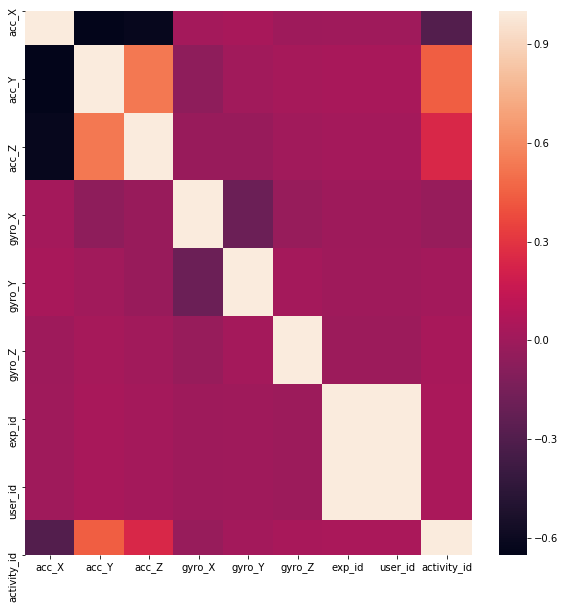

In [31]:
# matrice de correlation
corr = df_sensor.corr()
# generation d'une heatmap
fig, ax = plt.subplots(figsize=(10,10))  
sns.heatmap(corr,xticklabels=corr.columns, yticklabels=corr.columns)

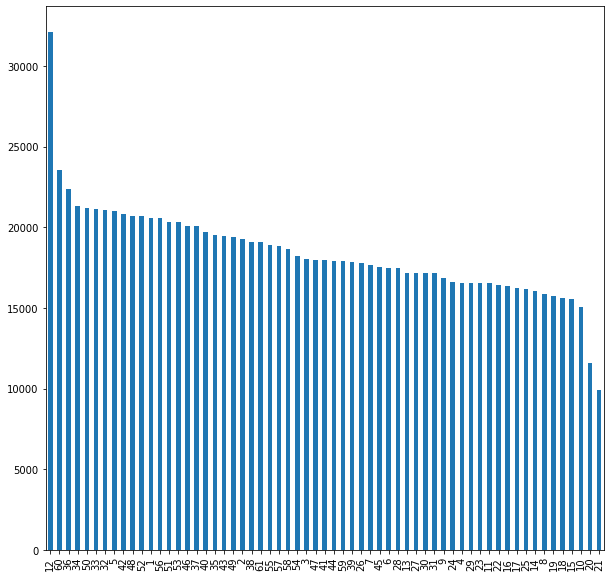

In [32]:
# nombre de signaux
# visualizing row numbers per dataframe

fig, ax = plt.subplots(figsize=(10,10))  
df_sensor['exp_id'].value_counts().plot(kind="bar")


In [33]:
# affichage du signal triaxial en fonction du gyro ou de l'acc
def plot_triaxial_signal(signal, activity_id):
    fig = plt.figure(figsize=(18,5))
    sampling_freq=50
    df = df_sensor[df_sensor["activity_id"] == activity_id]
    time=[1/float(sampling_freq) *j for j in range(df.shape[0])]
    _ =plt.plot(time,df[signal+ "_X"],color='r',label=signal+ "_x")
    _ =plt.plot(time,df[signal+ "_Y"],color='b',label=signal+ "_y")
    _ =plt.plot(time,df[signal+ "_Z"],color='g',label=signal+ "_z")
    _ = plt.legend(loc="upper left")# upper left corner
    plt.show()

Activity Labels 0    WALKING
Name: activity_labels, dtype: object


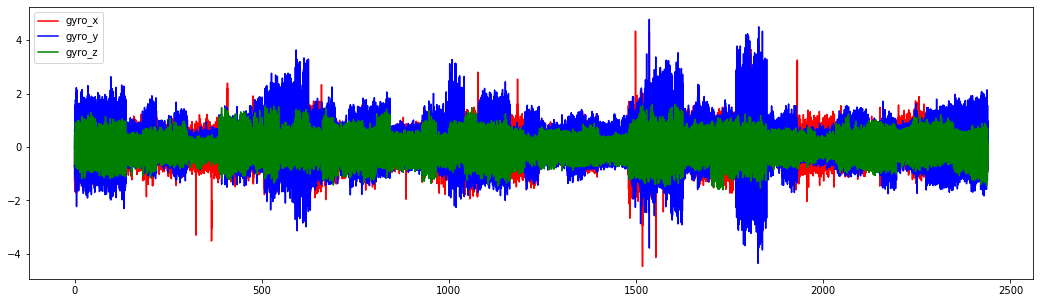

Activity Labels 1    WALKING_UPSTAIRS
Name: activity_labels, dtype: object


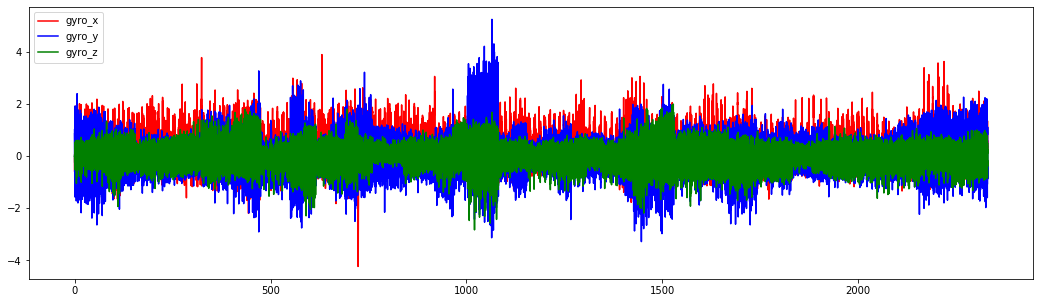

Activity Labels 2    WALKING_DOWNSTAIRS
Name: activity_labels, dtype: object


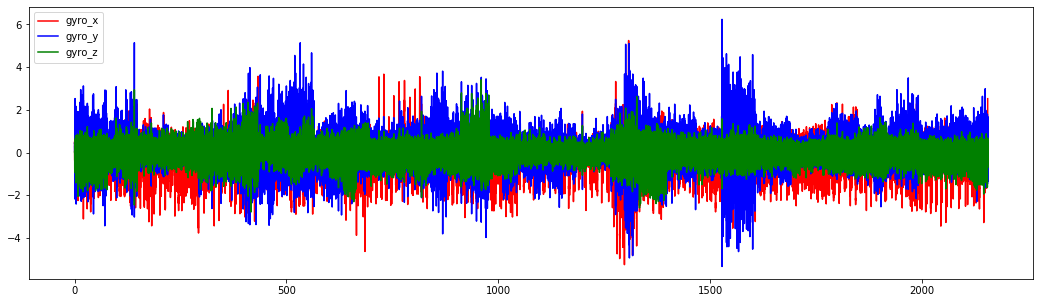

Activity Labels 3    SITTING
Name: activity_labels, dtype: object


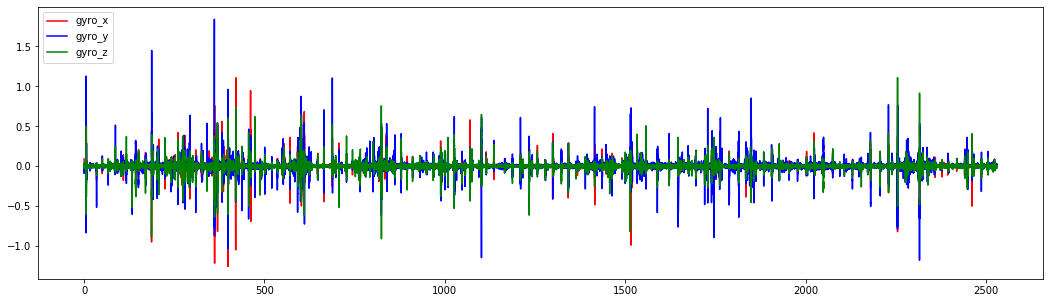

Activity Labels 4    STANDING
Name: activity_labels, dtype: object


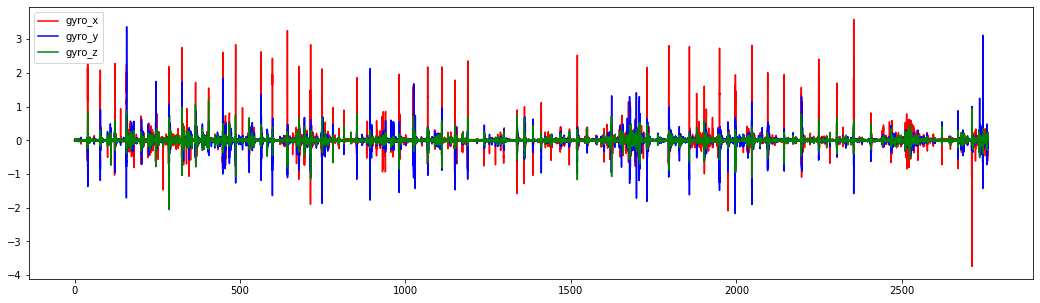

Activity Labels 5    LAYING
Name: activity_labels, dtype: object


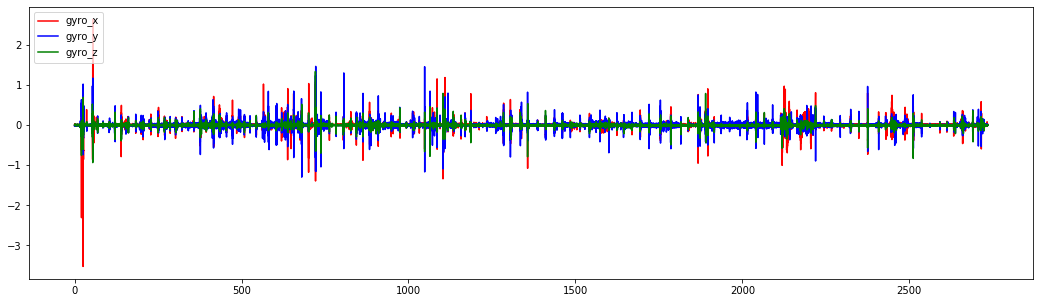

Activity Labels 6    STAND_TO_SIT
Name: activity_labels, dtype: object


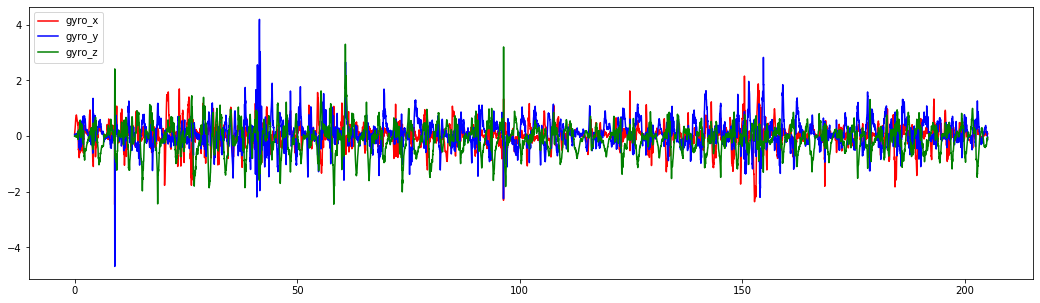

Activity Labels 7    SIT_TO_STAND
Name: activity_labels, dtype: object


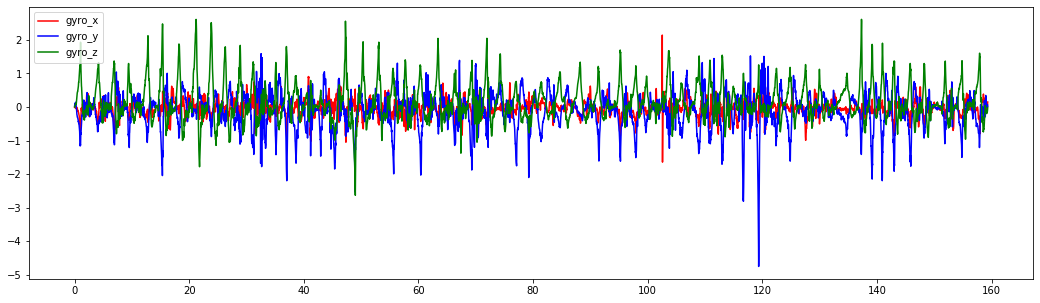

Activity Labels 8    SIT_TO_LIE
Name: activity_labels, dtype: object


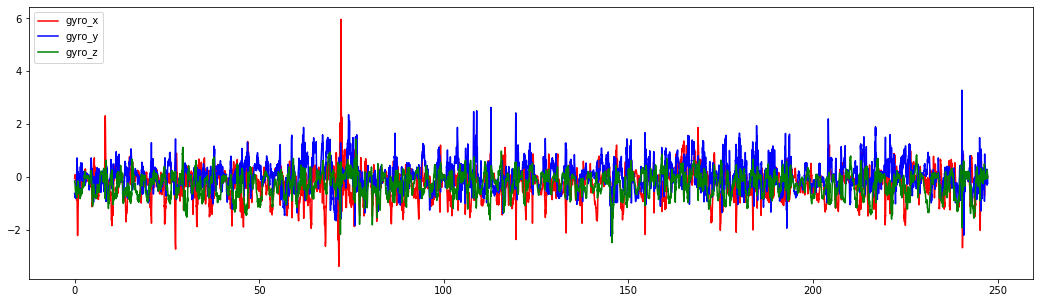

Activity Labels 9    LIE_TO_SIT
Name: activity_labels, dtype: object


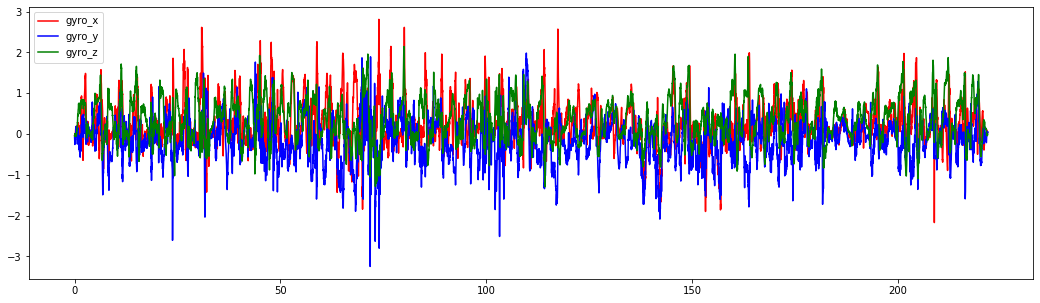

Activity Labels 10    STAND_TO_LIE
Name: activity_labels, dtype: object


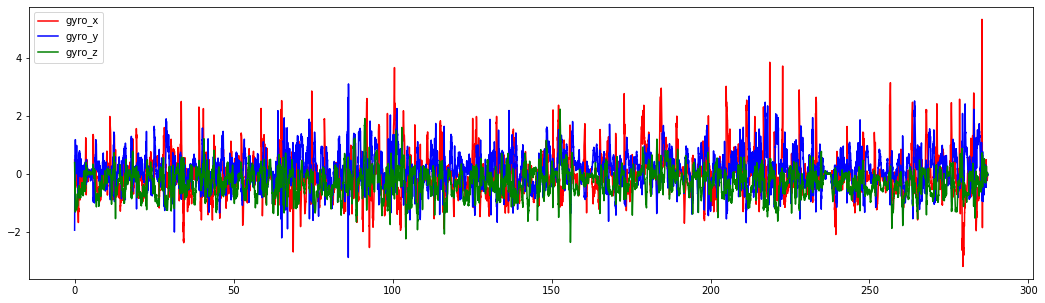

Activity Labels 11    LIE_TO_STAND
Name: activity_labels, dtype: object


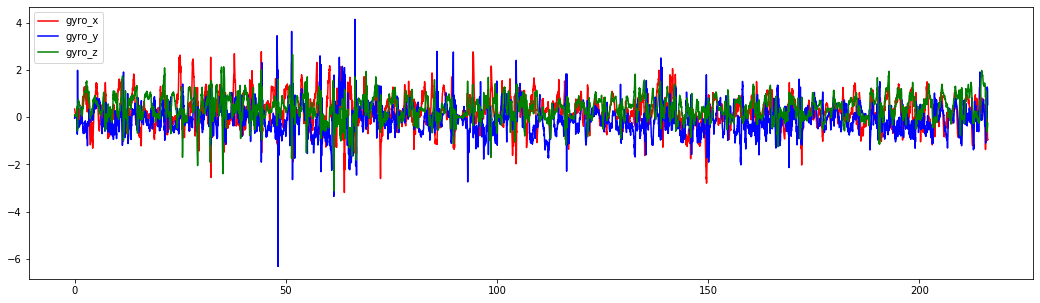

In [34]:
# activité depuis le gyro
for i in range(1,13):
    print("Activity Labels",activity_labels[activity_labels.activity_id == i].activity_labels)
    plot_triaxial_signal("gyro",i)

Activity Labels 0    WALKING
Name: activity_labels, dtype: object


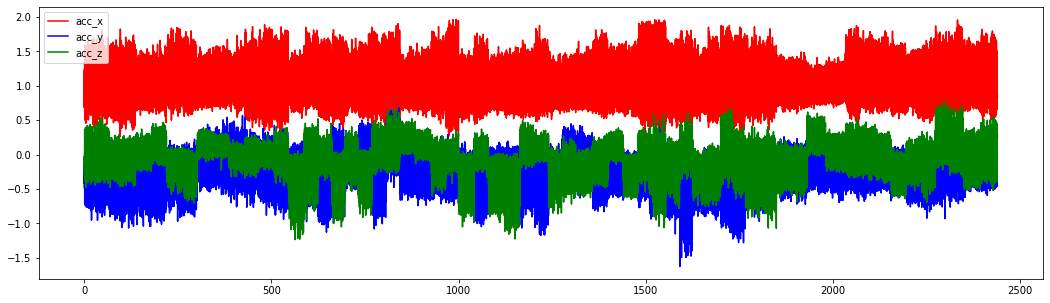

Activity Labels 1    WALKING_UPSTAIRS
Name: activity_labels, dtype: object


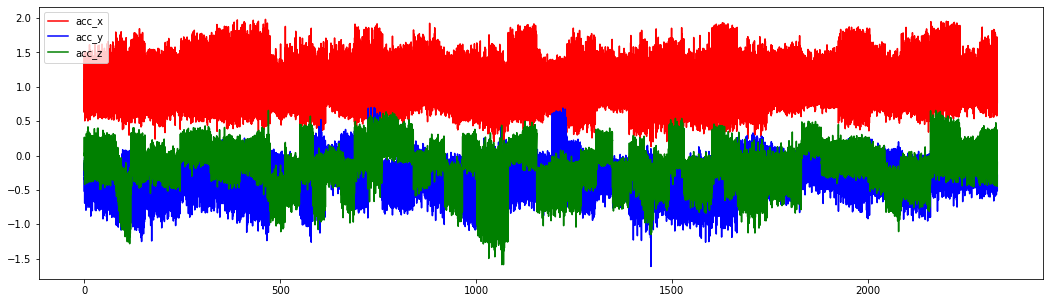

Activity Labels 2    WALKING_DOWNSTAIRS
Name: activity_labels, dtype: object


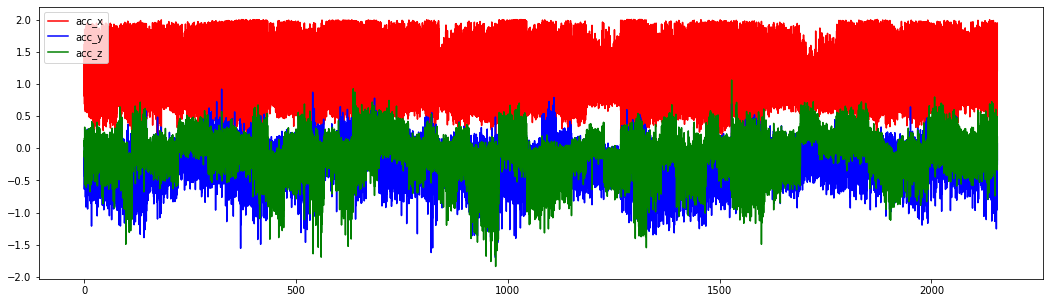

Activity Labels 3    SITTING
Name: activity_labels, dtype: object


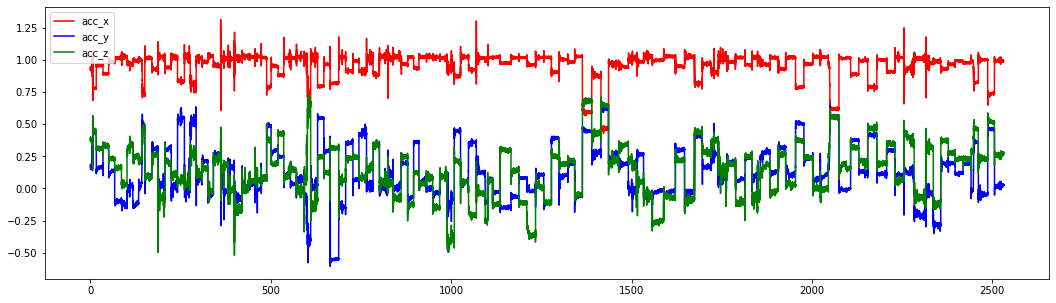

Activity Labels 4    STANDING
Name: activity_labels, dtype: object


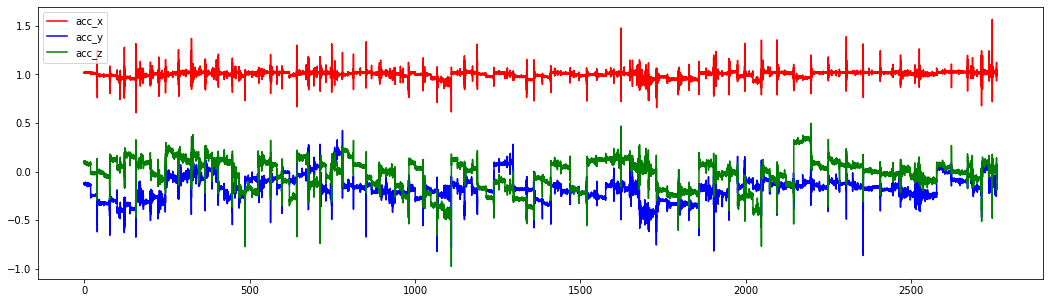

Activity Labels 5    LAYING
Name: activity_labels, dtype: object


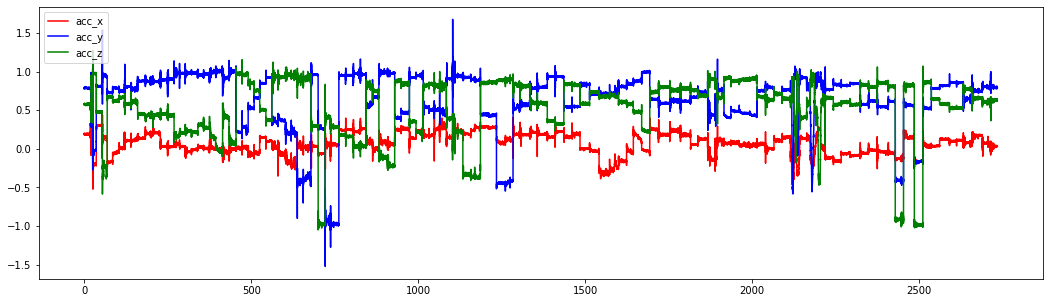

Activity Labels 6    STAND_TO_SIT
Name: activity_labels, dtype: object


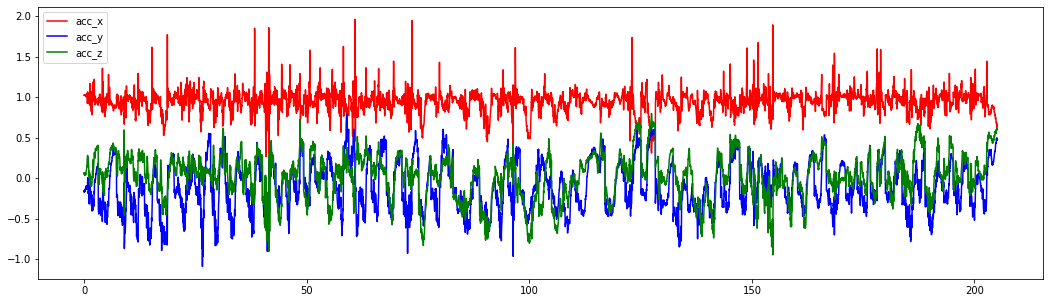

Activity Labels 7    SIT_TO_STAND
Name: activity_labels, dtype: object


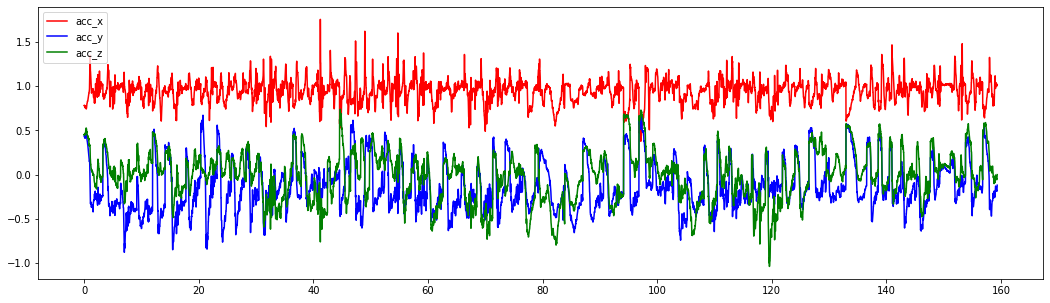

Activity Labels 8    SIT_TO_LIE
Name: activity_labels, dtype: object


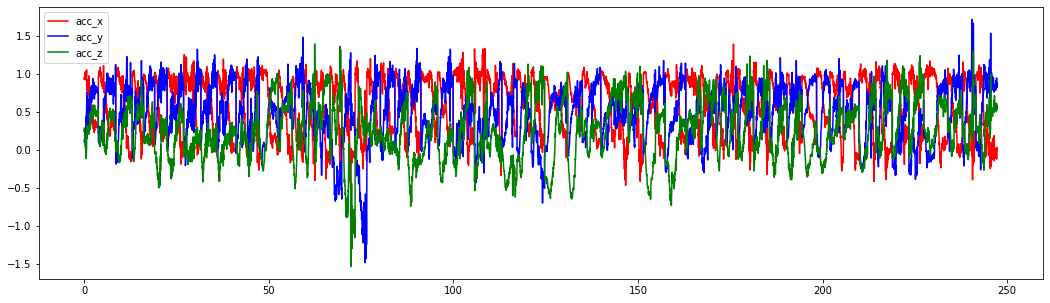

Activity Labels 9    LIE_TO_SIT
Name: activity_labels, dtype: object


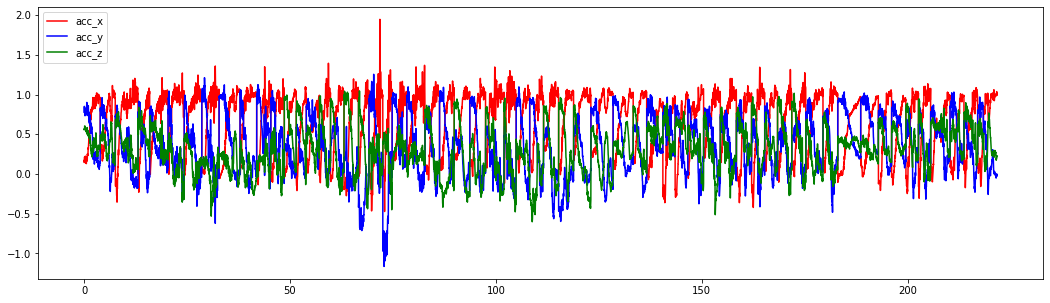

Activity Labels 10    STAND_TO_LIE
Name: activity_labels, dtype: object


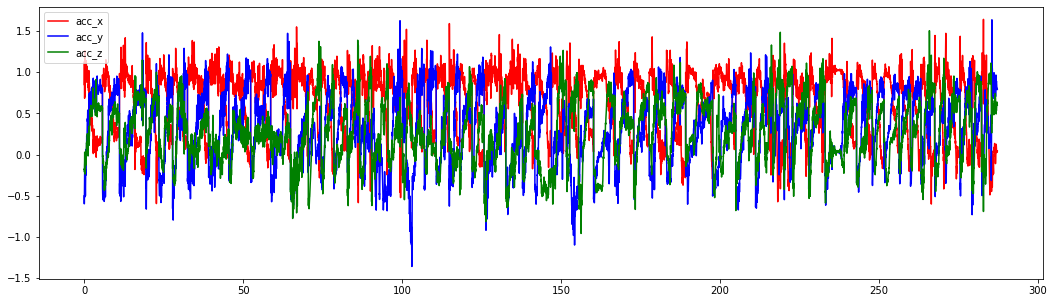

Activity Labels 11    LIE_TO_STAND
Name: activity_labels, dtype: object


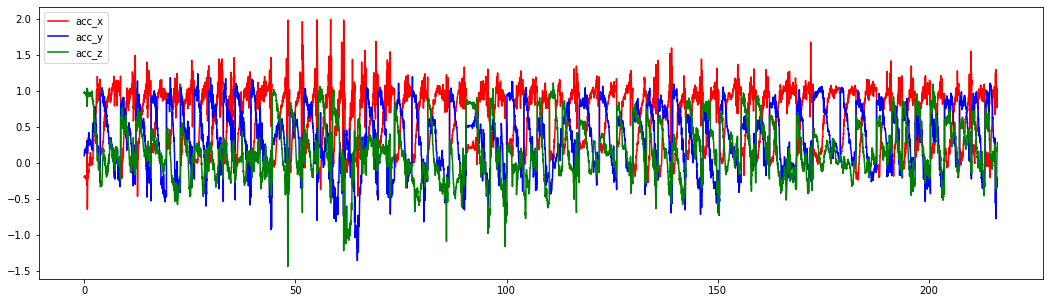

In [35]:
# activité depuis l'acc
for i in range(1,13):
    print("Activity Labels",activity_labels[activity_labels.activity_id == i].activity_labels)
    plot_triaxial_signal("acc",i)

# Model

## 1. Les enregistrements des fenêtres d'activité

In [53]:
# fonction dédie au lancement d'un model
ignore_cols = ['activity_id']
features = [feat for feat in df_train.columns if not feat in ignore_cols ]
def fit_from_model(model):
    X_train, X_test, y_train, y_test = train_test_split(df_train[features], df_train[ignore_cols], test_size=0.20, random_state=42)
    model.fit(X_train,y_train)
    scores = cross_val_score(t, X_test,y_test, cv=5)
    print(f"Accuracy {scores.mean()} (+/- {scores.std()*2})")
    return model

**Decision Tree Classifier**

In [54]:
t = tree.DecisionTreeClassifier(criterion='entropy')

In [55]:
model = fit_from_model(t)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_split.py:652: Warning: The least populated class in y has only 4 members, which is too few. The minimum number of members in any class cannot be less than n_splits=5.
  % (min_groups, self.n_splits)), Warning)


Accuracy 0.8700540649384824 (+/- 0.01984080464338534)


In [56]:
X_dev, y_dev = df_test[features], df_test[ignore_cols]

In [57]:
model.score(X_dev,y_dev)

0.8390259329538267

In [100]:
y_pred = model.predict(X_dev)

In [101]:
print("MSE",mean_squared_error(y_pred,y_dev))

MSE 0.6489563567362429


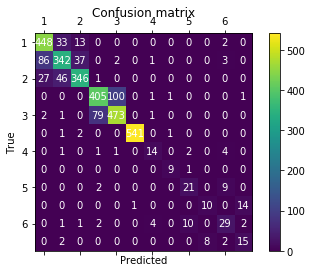

In [91]:
from sklearn.metrics import confusion_matrix

labels = [x for x in activity_labels.activity_id]
cm = confusion_matrix(y_dev, y_pred)
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix')
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('True')
thresh = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j]),
                ha="center", va="center",
                color="white") 
plt.show()

**Random Forest Classifier with grid search**

In [61]:
pipelines = make_pipeline(RandomForestClassifier())

In [64]:
X_train, X_test, y_train, y_test = train_test_split(df_train[features], df_train[ignore_cols], test_size=0.20, random_state=42)
parameters = {

    'randomforestclassifier__min_samples_leaf': (3, 4, 5),
    'randomforestclassifier__min_samples_split': (8, 10, 12),
 'randomforestclassifier__n_estimators': (20,50,100,200)
}
grid_search = GridSearchCV(pipelines,parameters,n_jobs=-1, verbose=1, cv=5)

In [65]:
grid_search.fit(X_test,y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/opt/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_split.py:652: Warning: The least populated class in y has only 4 members, which is too few. The minimum number of members in any class cannot be less than n_splits=5.
  % (min_groups, self.n_splits)), Warning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 180 out of 180 | elapsed:   49.6s finished
/opt/anaconda3/lib/python3.7/site-packages/sklearn/pipeline.py:267: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params)


GridSearchCV(cv=5, error_score='raise-deprecating',
       estimator=Pipeline(memory=None,
     steps=[('randomforestclassifier', RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_sam...bs=None,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False))]),
       fit_params=None, iid='warn', n_jobs=-1,
       param_grid={'randomforestclassifier__min_samples_leaf': (3, 4, 5), 'randomforestclassifier__min_samples_split': (8, 10, 12), 'randomforestclassifier__n_estimators': (20, 50, 100, 200)},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=1)

In [66]:
print(f"Best score: {grid_search.best_score_}")
print(f"Best parameters")
best_p =grid_search.best_estimator_.get_params()
for par_names in sorted(parameters.keys()):
    print(f"\t {par_names, best_p[par_names]}")

Best score: 0.9324324324324325
Best parameters
	 ('randomforestclassifier__min_samples_leaf', 3)
	 ('randomforestclassifier__min_samples_split', 10)
	 ('randomforestclassifier__n_estimators', 50)


In [97]:
y_pred = grid_search.predict(X_dev)

In [98]:
print("MSE",mean_squared_error(y_pred,y_dev))

MSE 0.9908285895003163


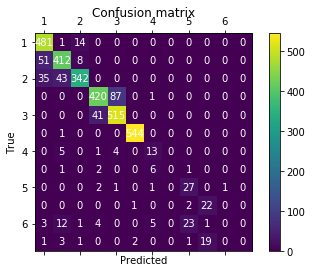

In [93]:
from sklearn.metrics import confusion_matrix

labels = [str(x) for x in activity_labels.activity_id]
cm = confusion_matrix(y_dev, y_pred)
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix')
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('True')
thresh = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j]),
                ha="center", va="center",
                color="white") 
plt.show()